(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
RowNumber          0
CustomerId         0
Surname            0
CreditScore   

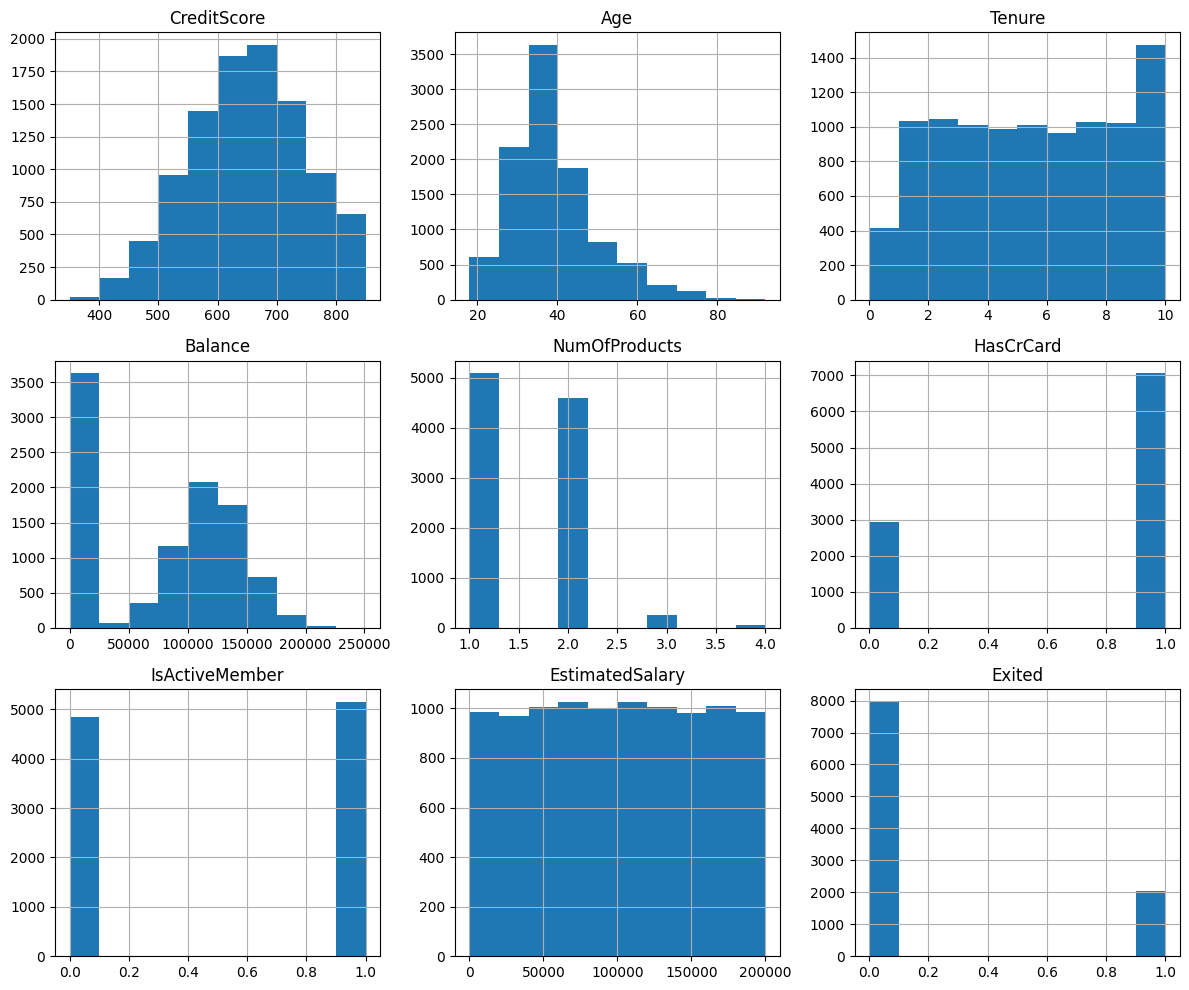

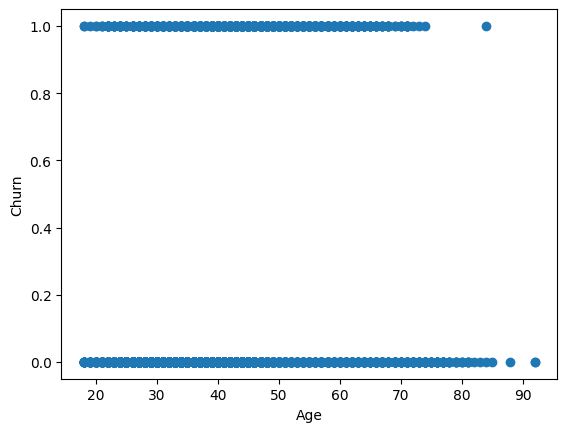

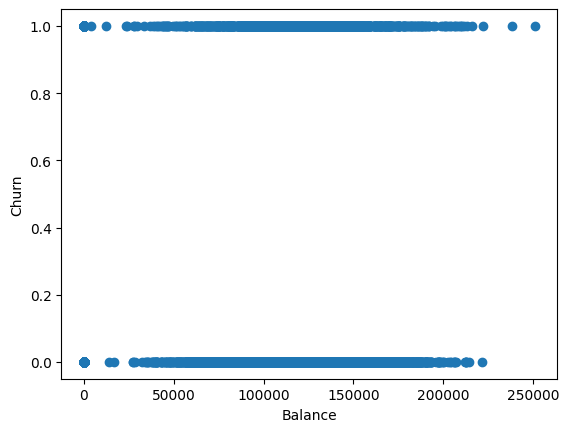

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64
Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("Churn_Modelling.csv")

# Basic info
print(df.shape)
print(df.info())
print(df.isnull().sum())

# Drop unnecessary columns
df = df.drop(['RowNumber','CustomerId','Surname'], axis=1)

# Check target distribution
print(df['Exited'].value_counts(normalize=True))

# Distribution plots
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

# Churn vs Age
plt.scatter(df['Age'], df['Exited'])
plt.xlabel("Age")
plt.ylabel("Churn")
plt.show()

# Churn vs Balance
plt.scatter(df['Balance'], df['Exited'])
plt.xlabel("Balance")
plt.ylabel("Churn")
plt.show()

# Group analysis
print(df.groupby('Geography')['Exited'].mean())
print(df.groupby('Gender')['Exited'].mean())

DATA PREPROCESSING + MODEL

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Convert categorical
df = pd.get_dummies(df, drop_first=True)

# Split
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Predict probability
df['Churn_Probability'] = model.predict_proba(X)[:,1]

# Risk segmentation
df['Risk_Level'] = pd.cut(df['Churn_Probability'],
                         bins=[0,0.3,0.7,1],
                         labels=['Low','Medium','High'])

# Add CustomerId back (optional)
original = pd.read_csv("Churn_Modelling.csv")
df['CustomerId'] = original['CustomerId']

# Save final dataset
df.to_csv("Predictive_Insights_Data.csv", index=False)